In [3]:
# Numerical operations
import numpy as np

# Dataset and train-test split
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Accuracy evaluation
from sklearn.metrics import accuracy_score

# Visualization
import matplotlib.pyplot as plt

In [4]:
# Load Breast Cancer Wisconsin dataset

data = load_breast_cancer()

# Features and target
X = data.data
y = data.target

# Print dataset information
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (569, 30)
Target vector shape: (569,)


In [5]:
# Split dataset:
# 80% training
# 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Print shapes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (455, 30)
Testing data shape: (114, 30)


In [6]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=300,     # Number of trees
    max_features="sqrt",  # Random feature selection
    oob_score=True,       # Enable OOB scoring
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [7]:
# Predictions on training data
y_train_pred = rf_model.predict(X_train)

# Predictions on testing data
y_test_pred = rf_model.predict(X_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# OOB score
oob_score = rf_model.oob_score_

# Print results
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("OOB Score:", oob_score)

Training Accuracy: 1.0
Testing Accuracy: 0.9649122807017544
OOB Score: 0.9648351648351648


In [8]:
print("Comparison of OOB Score and Testing Accuracy")
print()

print("OOB Score:", round(oob_score, 4))
print("Testing Accuracy:", round(test_accuracy, 4))

print()

if abs(oob_score - test_accuracy) < 0.05:
    print("OOB score is close to testing accuracy.")
    print("This indicates good generalization performance.")
else:
    print("There is a noticeable difference between OOB score and testing accuracy.")

Comparison of OOB Score and Testing Accuracy

OOB Score: 0.9648
Testing Accuracy: 0.9649

OOB score is close to testing accuracy.
This indicates good generalization performance.


In [12]:
# Different numbers of estimators
n_estimators_list = [50, 100, 200, 300]

# Different tree depths
max_depth_list = [1, 2, 5, 10]

# Dictionary to store results
results = {}

# Train models for all combinations
for depth in max_depth_list:

    accuracy_list = []

    for n in n_estimators_list:

        # Create Random Forest model
        model = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            max_features="sqrt",
            random_state=42
        )

        # Train model
        model.fit(X_train, y_train)

        # Predict on test data
        y_pred = model.predict(X_test)

        # Compute accuracy
        acc = accuracy_score(y_test, y_pred)

        # Store accuracy
        accuracy_list.append(acc)

    # Save results for current depth
    results[depth] = accuracy_list

In [13]:
print("Testing Accuracies for Different Hyperparameters")
print()

for depth, accuracies in results.items():

    print(f"Max Depth = {depth}")

    for n, acc in zip(n_estimators_list, accuracies):

        print(f"n_estimators = {n} --> Accuracy = {acc:.4f}")

    print()

Testing Accuracies for Different Hyperparameters

Max Depth = 1
n_estimators = 50 --> Accuracy = 0.9386
n_estimators = 100 --> Accuracy = 0.9561
n_estimators = 200 --> Accuracy = 0.9561
n_estimators = 300 --> Accuracy = 0.9561

Max Depth = 2
n_estimators = 50 --> Accuracy = 0.9561
n_estimators = 100 --> Accuracy = 0.9649
n_estimators = 200 --> Accuracy = 0.9649
n_estimators = 300 --> Accuracy = 0.9649

Max Depth = 5
n_estimators = 50 --> Accuracy = 0.9649
n_estimators = 100 --> Accuracy = 0.9649
n_estimators = 200 --> Accuracy = 0.9649
n_estimators = 300 --> Accuracy = 0.9649

Max Depth = 10
n_estimators = 50 --> Accuracy = 0.9649
n_estimators = 100 --> Accuracy = 0.9649
n_estimators = 200 --> Accuracy = 0.9649
n_estimators = 300 --> Accuracy = 0.9649



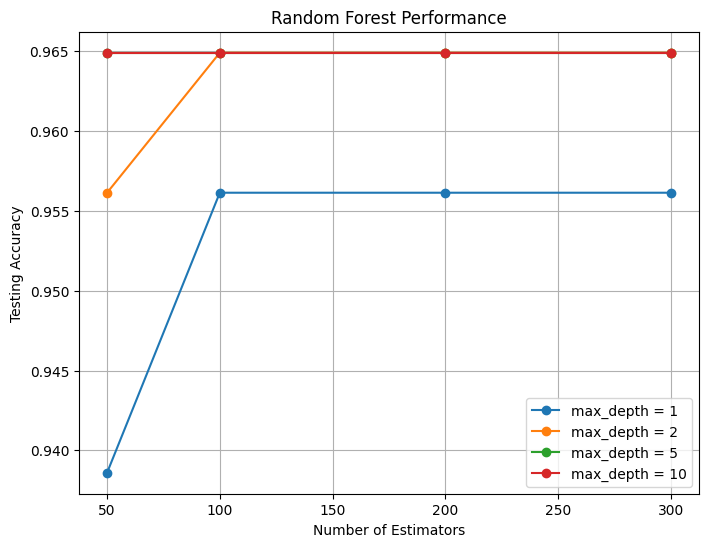

In [14]:
# Create figure
plt.figure(figsize=(8, 6))

# Plot accuracy curves for each max_depth
for depth, accuracies in results.items():

    plt.plot(
        n_estimators_list,
        accuracies,
        marker='o',
        label=f"max_depth = {depth}"
    )

# Labels and title
plt.xlabel("Number of Estimators")
plt.ylabel("Testing Accuracy")
plt.title("Random Forest Performance")

# Show legend
plt.legend()

# Show grid
plt.grid(True)

# Display plot
plt.show()